## Is there a gender gap in agency within sports?

#### Author : Luna Gourrier
#### Date : May 2026

To be noted
- booknlp is a library that requires specific versions of other packages. If you have troubles running this code, please use 3.11 and the following versions of specific packages : torch==2.1.0, tensorflow==2.13.0, spacy==3.7.4, thinc==8.2.5, pydantic==1.10.13 (both spacy dependencies), transformers==4.38.0.
- part of this code was generated thanks to IA (Claude)

## Introduction

Gender inequality in sports is well documented, yet it often manifests in subtle ways that are difficult to quantify. One such form of inequality lies in language itself: the way athletes are described in written texts can reflect and reinforce broader social norms about gender roles. In particular, the notion of agency — the degree to which an individual is portrayed as an active subject performing actions, rather than a passive object — has been identified as a key dimension of linguistic gender bias (Kypraiou & Petlacalco Barrios, 2022; Wagner et al., 2016). This asymmetry has also been observed in computational studies: Fu et al. (2016) used language models to quantify gender bias in sports journalism, while Biester (2025) demonstrated that large language models systematically retrieve men's results when gender is left ambiguous in sports-related prompts.

This project investigates whether such a bias exists in the way male and female athletes are represented in Wikipedia biographies. Specifically, we ask: are male athletes described with greater agency than female athletes, and does this difference vary depending on the type of sport? To address these questions, we scraped Wikipedia biographies of British athletes using the Wikipedia API. Focusing on a single nationality allows us to control for cultural and linguistic variation that could otherwise confound the results. Four sports are represented in our dataset: rugby and soccer, which are historically male-dominated, and figure skating and gymnastics, which are historically female-dominated. This design enables us to examine not only the overall gender gap in agency, but also whether the social norms associated with a given sport amplify or attenuate that gap.

To operationalize agency, we use a computational approach based on syntactic dependency parsing: for each biography, we count the number of verbs for which the athlete appears as the grammatical subject, normalized by the length of the biography. This measure is often referes to as "agentivity score". It captures how often an athlete is portrayed as doing something, as opposed to being simply described. 

The dataset includes 3092 lines and four columns: the athlete's name, their Wikipedia biography, a combined sport and gender label (e.g. Football_Men), and their nationality. Sixteen lines were removed before the analysis because of errors when counting the number of verbs. Therefor, the analysis was conducted on a dataset of 3076 lines.

To have a look at the scraping code, please refer to the file titled "CollecteDonneesAnglais.ipynb" in the folder "ExtraFiles".

## 1. Library import

In [57]:
import pandas as pd
import tempfile
from booknlp.booknlp import BookNLP
import re
import os
import sys
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import numpy as np

In [58]:
# Forcing UTF-8 everywhere to be able to read correctly biographies later
os.environ["PYTHONUTF8"] = "1"
os.environ["PYTHONIOENCODING"] = "utf-8"
os.environ["BOOKNLP_CACHE"] = r"C:\booknlp_cache" # To replace with your path
os.environ["HF_HOME"] = r"C:\hf_cache" # To replace with your path

In [59]:
df = pd.read_csv('english_athletes_1000_limit.csv')
df

,Name,Biography,Sport_Gender,Nationality
0,Arthur Aaron (footballer),Arthur Frederick Aaron (21 September 1885 – 10...,Football_Men,English
1,Max Aarons,Maximillian James Aarons (born 4 January 2000)...,Football_Men,English
2,Rolando Aarons,Rolando Aarons (born 16 November 1995) is a pr...,Football_Men,English
3,Thelo Aasgaard,"Thelonious ""Thelo"" Gerard Aasgaard (born 2 May...",Football_Men,English
4,Godwin Abadaki,Godwin Olorunfemi Ebenmosi Abadaki (born 12 Oc...,Football_Men,English
...,...,...,...,...
3087,Joyce Coates,Joyce Pamela Coates (born 14 December 1939 in ...,Figure_Skating_Women,English
3088,Lisa Cushley,Lisa Cushley (born 12 April 1969) is a British...,Figure_Skating_Women,English
3089,Stacey Kemp,Stacey King (née Kemp; born 25 July 1988) is a...,Figure_Skating_Women,English
3090,Kathleen Lovett,"Kathleen Marion Whyatt, née Lovett (30 Novembe...",Figure_Skating_Women,English


## 2. Getting the data

In [60]:
# Creating a function to initiate the model's parameters

model_path = r"C:\booknlp_models"
def init_booknlp():
    model_params = {
        "pipeline": "entity,quote,supersense,event,coref",
        "model": "big",
        "model_path": model_path # To replace with your path
    }
    return BookNLP("en", model_params)

In [61]:
# Creating the function that extracts the number of verbs per biography

def count_subject_verbs(name, biography, booknlp_model, output_dir="booknlp_output"):
    os.makedirs(output_dir, exist_ok=True)

    # Cleaning texts to make a correct analysis by removing and normalizing characters that could disrupt NLP analysis
    biography_clean = biography
    biography_clean = re.sub(r'\[.*?\]', '', biography_clean)
    biography_clean = re.sub(r'/[^/]+/', '', biography_clean)
    biography_clean = re.sub(r'\w+:\s*;', '', biography_clean)
    biography_clean = re.sub(r'\w+:\s+[^:]+:', ' ', biography_clean)
    biography_clean = re.sub(r'\s*==.*?==\s*', ' ', biography_clean)
    biography_clean = re.sub(r'\d{1,2}\s+\w+\s+\d{4}\s*[–-]\s*\d{1,2}\s+\w+\s+\d{4}', '', biography_clean)
    biography_clean = re.sub(r'\d{4}\s*[–-]\s*(\d{4}|after\s*\d{4}|before\s*\d{4})', '', biography_clean)
    biography_clean = re.sub(r'\d{4}\s*[–-]\s*\w+', '', biography_clean)
    biography_clean = re.sub(r'\d{4}/\d{4}', '', biography_clean)
    biography_clean = re.sub(r'née\s+\w+', '', biography_clean)
    biography_clean = biography_clean.replace(";", "")
    biography_clean = biography_clean.encode("cp1252", errors="ignore").decode("cp1252")
    biography_clean = re.sub(r'^(Log in|Sign in|Login)[\s\n]+', '', biography_clean, flags=re.IGNORECASE)
    biography_clean = biography_clean.replace("(", "").replace(")", "")


    # Writing the cleaned text to a temporary file and process it with BookNLP
    with tempfile.NamedTemporaryFile(mode="w", suffix=".txt",
                                     delete=False, encoding="utf-8") as f:
        f.write(biography_clean)
        tmp_path = f.name

    book_id = "bio"

    try:
        booknlp_model.process(tmp_path, output_dir, book_id)
    finally:
        os.remove(tmp_path)

    # Loading the .entities file and find the coreference cluster (COREF id) that corresponds to the athlete
    entities_path = os.path.join(output_dir, f"{book_id}.entities")
    entities_df = pd.read_csv(entities_path, sep="\t", quoting=3)  # quoting=3 prevents pandas from misinterpreting quotes inside the file

    # Cleaning the athlete's name
    name_clean = re.sub(r'\(.*?\)', '', name).strip()
    name_clean = re.sub(r'\b(Sr|Jr|Sr\.|Jr\.)\b', '', name_clean).strip()
    last_name = name_clean.split()[-1].lower()

    # Normalize hyphens in entity text for better matching
    entities_text_normalized = entities_df["text"].str.lower().str.replace(" - ", "-", regex=False)

    # Searching for the athlete by last name first
    match = entities_df[
        entities_text_normalized.str.contains(last_name, na=False, regex=False)
    ]

    # Searching by full name if last name not found
    if match.empty:
        full_name = name_clean.lower()
        match = entities_df[
            entities_text_normalized.str.contains(full_name, na=False, regex=False)
        ]

    # Search by first name if full name not found
    if match.empty:
        first_name = name_clean.split()[0].lower()
        match = entities_df[
            entities_text_normalized.str.contains(first_name, na=False, regex=False)
        ]

    # If no mention found, return empty results
    if match.empty:
        return {"verb_count": 0, "verbs": [], "coref_id": None,
                "active_count": 0, "passive_count": 0,
                "active_verbs": [], "passive_verbs": [],
                "warning": f"Aucune mention trouvée pour '{name}'"}
        
    # Select the most frequent COREF id among matched mentions
    coref_id = match["COREF"].value_counts().idxmax()

    # Collecting all token ids that belong to any mention of the athlete
    person_mentions = entities_df[entities_df["COREF"] == coref_id]
    person_token_ids = set()
    for _, row in person_mentions.iterrows():
        for tok_id in range(int(row["start_token"]), int(row["end_token"]) + 1):
            person_token_ids.add(tok_id)

    # Loading the .tokens file and find verbs for which the athlete is the subject           
    tokens_path = os.path.join(output_dir, f"{book_id}.tokens")
    tokens_df = pd.read_csv(tokens_path, sep="\t", quoting=3)
    
    # Find tokens that belong to the athlete and are syntactic subjects
    subject_relations = {"nsubj", "nsubjpass"}
    subject_tokens = tokens_df[
        (tokens_df["token_ID_within_document"].isin(person_token_ids)) &
        (tokens_df["dependency_relation"].isin(subject_relations))
    ]

    # Separating active subjects (nsubj) from passive subjects (nsubjpass) and retrieve the ids of their head verbs  
    # int() conversion is necessary because syntactic_head_ID is stored as string
    active_head_ids = [int(x) for x in subject_tokens[subject_tokens["dependency_relation"] == "nsubj"]["syntactic_head_ID"].tolist()]
    passive_head_ids = [int(x) for x in subject_tokens[subject_tokens["dependency_relation"] == "nsubjpass"]["syntactic_head_ID"].tolist()]

    # Handling csubj question : if a verb head has dependency relation "csubj", it means the athlete's name is used as a clausal subject
    # We climb one level up to reach the actual main verb.
    expanded_active_ids = []
    for hid in active_head_ids:
        expanded_active_ids.append(hid)
        head_row = tokens_df[tokens_df["token_ID_within_document"] == hid]
        if not head_row.empty and head_row.iloc[0]["dependency_relation"] == "csubj":
            expanded_active_ids.append(int(head_row.iloc[0]["syntactic_head_ID"]))
    active_head_ids = expanded_active_ids

    expanded_passive_ids = []
    for hid in passive_head_ids:
        expanded_passive_ids.append(hid)
        head_row = tokens_df[tokens_df["token_ID_within_document"] == hid]
        if not head_row.empty and head_row.iloc[0]["dependency_relation"] == "csubj":
            expanded_passive_ids.append(int(head_row.iloc[0]["syntactic_head_ID"]))
    passive_head_ids = expanded_passive_ids

    # Handling who dependency question
    who_tokens = tokens_df[
        (tokens_df["word"].str.lower().isin(["who", "which"])) &
        (tokens_df["dependency_relation"].isin({"nsubj", "nsubjpass"}))
    ]
    for _, who_tok in who_tokens.iterrows():
        who_id = int(who_tok["token_ID_within_document"])
        who_head_id = int(who_tok["syntactic_head_ID"])
        prev_token_id = who_id - 1
        if prev_token_id in person_token_ids:
            if who_tok["dependency_relation"] == "nsubj":
                active_head_ids.append(who_head_id)
            else:
                passive_head_ids.append(who_head_id)

    # Handling coordinated verbs question
    active_conj = tokens_df[
        (tokens_df["syntactic_head_ID"].isin(active_head_ids)) &
        (tokens_df["dependency_relation"] == "conj") &
        (tokens_df["POS_tag"] == "VERB")
    ]["token_ID_within_document"].tolist()

    passive_conj = tokens_df[
        (tokens_df["syntactic_head_ID"].isin(passive_head_ids)) &
        (tokens_df["dependency_relation"] == "conj") &
        (tokens_df["POS_tag"] == "VERB")
    ]["token_ID_within_document"].tolist()

    # Retreiving verb lemmas and returning results
    active_verbs = tokens_df[tokens_df["token_ID_within_document"].isin(active_head_ids + active_conj)]["lemma"].tolist()
    passive_verbs = tokens_df[tokens_df["token_ID_within_document"].isin(passive_head_ids + passive_conj)]["lemma"].tolist()

    verbs = active_verbs + passive_verbs

    return {
        "verb_count": len(verbs),
        "verbs": verbs,
        "active_count": len(active_verbs),
        "passive_count": len(passive_verbs),
        "active_verbs": active_verbs,
        "passive_verbs": passive_verbs,
        "coref_id": coref_id
    }

In [62]:
def process_dataset(df, name_col, bio_col, test_only=False, output_dir="booknlp_output", save_path=None):
    df_processed = df.copy()

    # Creating a condition to test only the first line
    if test_only:      
        df_processed = df_processed.iloc[:1].copy()
        print(f"Mode test — traitement de : {df_processed[name_col].iloc[0]}")

    booknlp_model = init_booknlp()

    # Initializing new columns
    for col in ["verb_count", "verbs", "active_count", "passive_count", "active_verbs", "passive_verbs"]:
        if col not in df_processed.columns:
            df_processed[col] = None

    for i, row in df_processed.iterrows():
        # Cheking line has not already been analyzed
        if pd.notna(df_processed.at[i, "verb_count"]):
            print(f"[{i+1}] Déjà traité : {row[name_col]}")
            continue

        print(f"[{i+1}/{len(df_processed)}] Traitement de : {row[name_col]}")

        try:
            result = count_subject_verbs(row[name_col], row[bio_col], booknlp_model, output_dir=output_dir)
        except Exception as e:
            print(f"  ERREUR : {e}")
            result = {
                "verb_count": -1,
                "verbs": [],
                "active_count": -1,
                "passive_count": -1,
                "active_verbs": [],
                "passive_verbs": [],
                "coref_id": None
            }

        # Adding results to the dataset
        df_processed.at[i, "verb_count"]    = result["verb_count"]
        df_processed.at[i, "verbs"]         = str(result["verbs"])
        df_processed.at[i, "active_count"]  = result["active_count"]
        df_processed.at[i, "passive_count"] = result["passive_count"]
        df_processed.at[i, "active_verbs"]  = str(result["active_verbs"])
        df_processed.at[i, "passive_verbs"] = str(result["passive_verbs"])

        # Saving temporary the results only if a path was given
        if save_path and (i + 1) % 10 == 0:
            df_processed.to_csv(save_path, index=False)
            print(f"  Sauvegarde intermédiaire à la ligne {i+1}")

    # Final saving if asked
    if save_path:
        df_processed.to_csv(save_path, index=False)
        print("Terminé ! Résultats sauvegardés dans", save_path)
    else:
        print("Terminé ! Le DataFrame a été mis à jour avec succès.")

    return df_processed

In [63]:
# Testing the functions on the first line of the dataset

df_test = process_dataset(
    df=df, 
    name_col="Name",
    bio_col="Biography",
    test_only=True,
    output_dir=r"C:\booknlp_output",
    save_path=None # To replace with a path if you want to save the result
)
df_test

Mode test — traitement de : Arthur Aaron (footballer)
{'pipeline': 'entity,quote,supersense,event,coref', 'model': 'big', 'model_path': 'C:\\booknlp_models'}


c:\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


--- startup: 15.013 seconds ---
[1/1] Traitement de : Arthur Aaron (footballer)
--- spacy: 0.170 seconds ---
--- entities: 1.208 seconds ---
--- quotes: 0.000 seconds ---
--- attribution: 0.000 seconds ---
--- name coref: 0.009 seconds ---
--- coref: 3.101 seconds ---
--- TOTAL (excl. startup): 4.539 seconds ---, 110 words
Terminé ! Le DataFrame a été mis à jour avec succès.


,Name,Biography,Sport_Gender,Nationality,verb_count,verbs,active_count,passive_count,active_verbs,passive_verbs
0,Arthur Aaron (footballer),Arthur Frederick Aaron (21 September 1885 – 10...,Football_Men,English,8,"['be', 'be', 'become', 'marry', 'change', 'die...",6,2,"['be', 'be', 'become', 'marry', 'change', 'die']","['bear', 'baptise']"


In [64]:
# Getting all results

df_full = process_dataset(
    df=df, 
    name_col="Name",
    bio_col="Biography",
    test_only=False,
    output_dir=r"C:\booknlp_output", # To replace if your path is different
    save_path= None) # To replace with your path if you want to save it as safety

{'pipeline': 'entity,quote,supersense,event,coref', 'model': 'big', 'model_path': 'C:\\booknlp_models'}


c:\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


--- startup: 9.783 seconds ---
[1/3092] Traitement de : Arthur Aaron (footballer)
--- spacy: 0.024 seconds ---
--- entities: 0.612 seconds ---
--- quotes: 0.000 seconds ---
--- attribution: 0.000 seconds ---
--- name coref: 0.000 seconds ---
--- coref: 2.833 seconds ---
--- TOTAL (excl. startup): 3.520 seconds ---, 110 words
[2/3092] Traitement de : Max Aarons
--- spacy: 0.103 seconds ---
--- entities: 1.057 seconds ---
--- quotes: 0.000 seconds ---
--- attribution: 0.000 seconds ---
--- name coref: 0.000 seconds ---
--- coref: 2.949 seconds ---
--- TOTAL (excl. startup): 4.217 seconds ---, 194 words
[3/3092] Traitement de : Rolando Aarons
--- spacy: 0.049 seconds ---
--- entities: 0.431 seconds ---
--- quotes: 0.000 seconds ---
--- attribution: 0.000 seconds ---
--- name coref: 0.000 seconds ---
--- coref: 2.685 seconds ---
--- TOTAL (excl. startup): 3.226 seconds ---, 73 words
[4/3092] Traitement de : Thelo Aasgaard
--- spacy: 0.028 seconds ---
--- entities: 0.264 seconds ---
--- quo

In [65]:
df_full

,Name,Biography,Sport_Gender,Nationality,verb_count,verbs,active_count,passive_count,active_verbs,passive_verbs
0,Arthur Aaron (footballer),Arthur Frederick Aaron (21 September 1885 – 10...,Football_Men,English,8,"['be', 'be', 'become', 'marry', 'change', 'die...",6,2,"['be', 'be', 'become', 'marry', 'change', 'die']","['bear', 'baptise']"
1,Max Aarons,Maximillian James Aarons (born 4 January 2000)...,Football_Men,English,9,"['bear', 'join', 'go', 'become', 'join', 'prom...",5,4,"['bear', 'join', 'go', 'become', 'join']","['promote', 'relegate', 'send', 'join']"
2,Rolando Aarons,Rolando Aarons (born 16 November 1995) is a pr...,Football_Men,English,4,"['bear', 'be', 'represent', 'have']",4,0,"['bear', 'be', 'represent', 'have']",[]
3,Thelo Aasgaard,"Thelonious ""Thelo"" Gerard Aasgaard (born 2 May...",Football_Men,English,1,['bear'],1,0,['bear'],[]
4,Godwin Abadaki,Godwin Olorunfemi Ebenmosi Abadaki (born 12 Oc...,Football_Men,English,3,"['bear', 'play', 'loan']",3,0,"['bear', 'play', 'loan']",[]
...,...,...,...,...,...,...,...,...,...,...
3087,Joyce Coates,Joyce Pamela Coates (born 14 December 1939 in ...,Figure_Skating_Women,English,1,['bear'],1,0,['bear'],[]
3088,Lisa Cushley,Lisa Cushley (born 12 April 1969) is a British...,Figure_Skating_Women,English,2,"['bear', 'finish']",2,0,"['bear', 'finish']",[]
3089,Stacey Kemp,Stacey King (née Kemp; born 25 July 1988) is a...,Figure_Skating_Women,English,2,"['bear', 'be']",2,0,"['bear', 'be']",[]
3090,Kathleen Lovett,"Kathleen Marion Whyatt, née Lovett (30 Novembe...",Figure_Skating_Women,English,2,"['be', 'compete']",2,0,"['be', 'compete']",[]


In [66]:
# Checking if there are mistakes in the dataset 

# Lines with 0 verbs
zero_verbs = df_full[df_full["verb_count"] == 0]
print(f"Lines with 0 verbs : {len(zero_verbs)} / {len(df_full)}")

# Lines with an error (number of verbs < 0)
errors = df_full[df_full["verb_count"] == -1]
print(f"Lignes avec erreur : {len(errors)} / {len(df_full)}")

# Printing some examples of lines with 0 verbs
print("\nExamples of lines with 0 verb :")
print(zero_verbs[["Name", "Biography"]].head(10).to_string())

Lines with 0 verbs : 15 / 3092
Lignes avec erreur : 3 / 3092

Examples of lines with 0 verb :
                            Name                                                                                                                                                                                                                                                                                                       Biography
502           Ethan Amundsen-Day                                                                                                                  Ethan Amundsen-Day (born 9 May 2005) is a professional footballer who plays as a centre-back for Eliteserien club HamKam. Born in England, he represented Norway at youth international level.
814            Benny Ashley-Seal                                                                                                                                        Bernard Patrick Ashley-Seal (born 21 November 1998) is an Englis

These problematic entries were excluded from the dataset as they could not be resolved. We opted against manual correction to avoid introducing human bias and to maintain consistency; using a uniform automated pipeline with BookNLP and spaCy ensures that all data is treated identically, despite the inherent limitations of computational analysis.

## 3. Analysis

To analyze the results, the first step is to create ratios. Indeed, biographies length vary so this is a bias to be taken into account. 

In [67]:
# Deleting lines with errors

df_analysis = df_full[df_full['verb_count']>0]
df_analysis = df_full.reset_index(drop=True)

In [68]:
# Creating ratio columns for every type of verb to avoid the bias of the length of the text

for i in range(len(df_analysis)):
    df_analysis.loc[i, 'active_count_len_ratio']= (df_analysis.loc[i, 'active_count']) / (len(df_analysis.loc[i, 'Biography'].split()))
    df_analysis.loc[i, 'passive_count_len_ratio'] = df_analysis.loc[i, 'passive_count'] / len(df_analysis.loc[i, 'Biography'].split())
    df_analysis.loc[i, 'verb_len_ratio'] = df_analysis.loc[i, 'verb_count'] / len(df_analysis.loc[i, 'Biography'].split()) 

In [69]:
df_analysis

,Name,Biography,Sport_Gender,Nationality,verb_count,verbs,active_count,passive_count,active_verbs,passive_verbs,active_count_len_ratio,passive_count_len_ratio,verb_len_ratio
0,Arthur Aaron (footballer),Arthur Frederick Aaron (21 September 1885 – 10...,Football_Men,English,8,"['be', 'be', 'become', 'marry', 'change', 'die...",6,2,"['be', 'be', 'become', 'marry', 'change', 'die']","['bear', 'baptise']",0.058824,0.019608,0.078431
1,Max Aarons,Maximillian James Aarons (born 4 January 2000)...,Football_Men,English,9,"['bear', 'join', 'go', 'become', 'join', 'prom...",5,4,"['bear', 'join', 'go', 'become', 'join']","['promote', 'relegate', 'send', 'join']",0.028902,0.023121,0.052023
2,Rolando Aarons,Rolando Aarons (born 16 November 1995) is a pr...,Football_Men,English,4,"['bear', 'be', 'represent', 'have']",4,0,"['bear', 'be', 'represent', 'have']",[],0.063492,0.000000,0.063492
3,Thelo Aasgaard,"Thelonious ""Thelo"" Gerard Aasgaard (born 2 May...",Football_Men,English,1,['bear'],1,0,['bear'],[],0.032258,0.000000,0.032258
4,Godwin Abadaki,Godwin Olorunfemi Ebenmosi Abadaki (born 12 Oc...,Football_Men,English,3,"['bear', 'play', 'loan']",3,0,"['bear', 'play', 'loan']",[],0.073171,0.000000,0.073171
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3087,Joyce Coates,Joyce Pamela Coates (born 14 December 1939 in ...,Figure_Skating_Women,English,1,['bear'],1,0,['bear'],[],0.014925,0.000000,0.014925
3088,Lisa Cushley,Lisa Cushley (born 12 April 1969) is a British...,Figure_Skating_Women,English,2,"['bear', 'finish']",2,0,"['bear', 'finish']",[],0.040000,0.000000,0.040000
3089,Stacey Kemp,Stacey King (née Kemp; born 25 July 1988) is a...,Figure_Skating_Women,English,2,"['bear', 'be']",2,0,"['bear', 'be']",[],0.064516,0.000000,0.064516
3090,Kathleen Lovett,"Kathleen Marion Whyatt, née Lovett (30 Novembe...",Figure_Skating_Women,English,2,"['be', 'compete']",2,0,"['be', 'compete']",[],0.066667,0.000000,0.066667


Now, all data are available to make the analysis.

## 3.1 Analyze per gender

### 3.1.2 Graphical display

In [70]:
df_analysis['Gender'] = df_analysis['Sport_Gender'].str.rsplit('_', n=1).str[-1] # creating a column only with the gender of the athlete

([<matplotlib.axis.XTick at 0x1f1f2f57050>,
 [Text(0, 0, 'Men'), Text(1, 0, 'Women')])

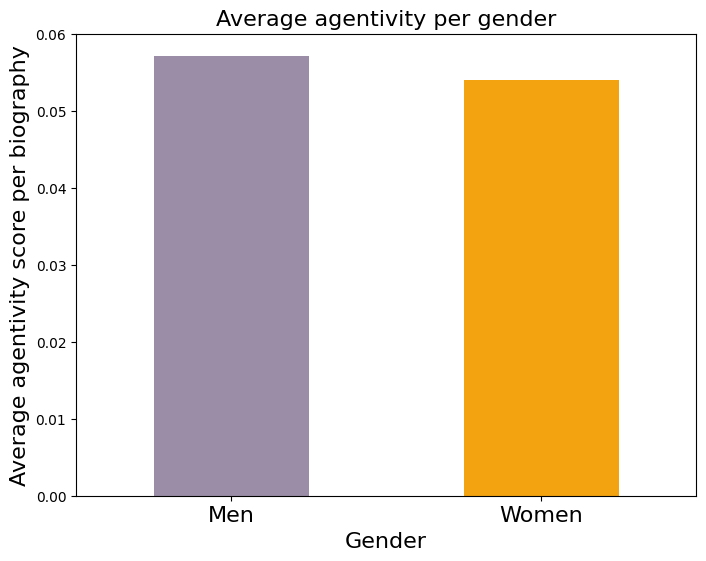

In [71]:
# Printing results

gender_means = df_analysis.groupby('Gender')['verb_len_ratio'].mean()

plt.figure(figsize=(8, 6))

gender_means.plot(kind='bar', color=["#9b8da8", "#F3A310"])

plt.title('Average agentivity per gender', fontsize=16)
plt.xlabel('Gender', fontsize=16)
plt.ylabel('Average agentivity score per biography', fontsize=16)
plt.xticks([0, 1], ['Men', 'Women'], rotation=0, fontsize=16)


In [72]:
print(f'The score of agentivity for men is {gender_means["Men"].round(3)}. The score of agentivity for women is {gender_means["Women"].round(3)}. Therefore, men are more agentive than women by 0.003 points.')

The score of agentivity for men is 0.057. The score of agentivity for women is 0.054. Therefore, men are more agentive than women by 0.003 points.


Graphics seem to indicate that men are slightly more agentive than women but let's check this thanks to statistical analysis.

### 3.1.3 Statistical analysis

To decide which statistical test should be used, we first need to understand the distribution of the variable gender. To do so, we will use a Shapiro-Wilk test. If the distribution is normal, a T-test will be done, otherwise we'll do a Mann Whitney U-test.

In [73]:
# Testing the distribution

df_stats = df_analysis.copy()

men = df_stats[df_stats['Gender'] == 'Men']['verb_len_ratio'].dropna()
women = df_stats[df_stats['Gender'] == 'Women']['verb_len_ratio'].dropna()

stat_h, p_norm_h = stats.shapiro(men)
stat_f, p_norm_f = stats.shapiro(women)
print(f"[Normality] Men group : p-value = {p_norm_h:.4f}")
print(f"[Normality] Women group : p-value = {p_norm_f:.4f}")

if p_norm_h < 0.05 or p_norm_f < 0.05:
    print("-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).")
else:
    print("-> The data are normally distributed. Using Student's t-test.")

[Normality] Men group : p-value = 0.0000
[Normality] Women group : p-value = 0.0000
-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).


In [74]:
# Performing Mann-Whitney test

stat_mw, p_mw = stats.mannwhitneyu(men, women, alternative='two-sided')
print(f"\nMann-Whitney results : p-value = {p_mw:.4e}")

if p_mw < 0.05:
    print("-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).")
else:
    print("-> CONCLUSION: The difference in agency is not statistically significant.")



Mann-Whitney results : p-value = 3.4655e-08
-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).


## 3.2 Analyze per gender per sport category

### 3.2.1 Graphical display

In [94]:
df_analysis['Sport'] = df_analysis['Sport_Gender'].str.rsplit('_', n=1).str[0] # creating a column only with the sport of the athlete

In [95]:
# Defining sports categories

dictionnary_of__categories = {
    'Football': 'Historically_male',
    'Rugby': 'Historically_male',
    'Gymnastics': 'Historically_female',
    'Figure_Skating': 'Historically_female'
}

df_analysis['sport_type'] = df_analysis['Sport'].map(dictionnary_of__categories)

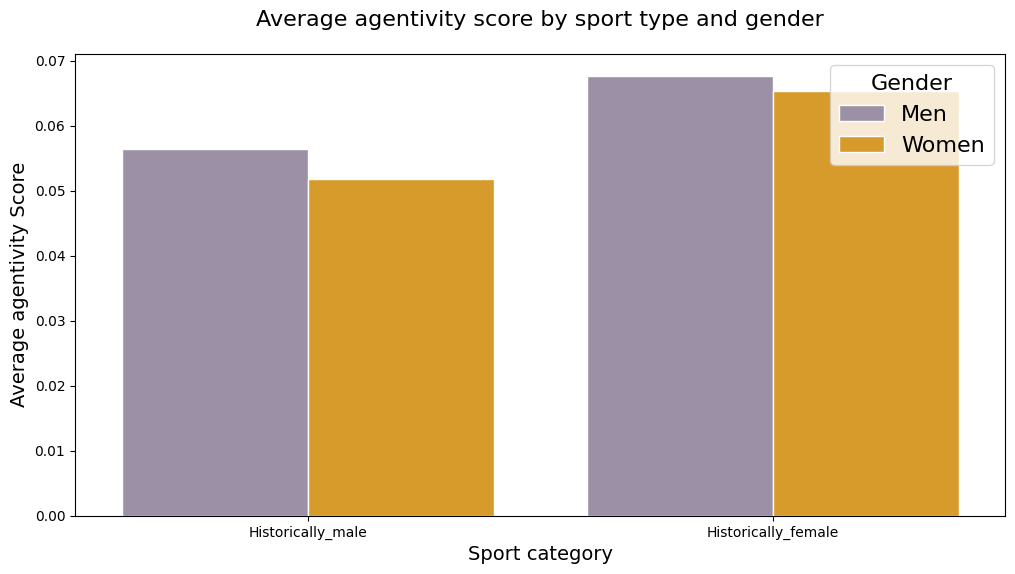

In [96]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_analysis, 
    x='sport_type',  
    y='verb_len_ratio', 
    hue='Gender',        
    palette={"Men": "#9b8da8", "Women": "#F3A310"}, 
    errorbar=None,       
    
    edgecolor='white'
)

plt.title('Average agentivity score by sport type and gender', fontsize=16, pad=20)
plt.xlabel('Sport category', fontsize=14)
plt.ylabel('Average agentivity Score', fontsize=14)
plt.legend(title='Gender', title_fontsize='16', fontsize='16')

It seems that in both sports categories, men are more agentive than women. Let's check this with a statistical test.

### 3.2.2 Statistical analysis

Text(0, 0.5, 'Frequency')

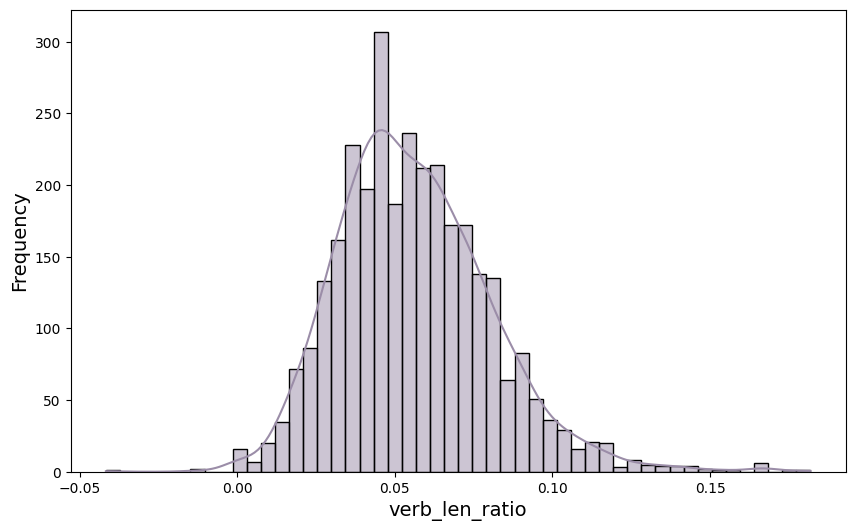

In [78]:
# Checking distribution of verb_len_ratio

plt.figure(figsize=(10, 6))

# Printing histogramm of the variable
sns.histplot(df_analysis['verb_len_ratio'], kde=True, color="#9b8da8", bins=50)

plt.xlabel('verb_len_ratio', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

The variable is log distributed.

To examine the influence of gender and sport type on agentivity, we conducted a two-way ANOVA on the log-transformed verb_len_ratio. The log-transformation was necessary to address the right-skewed nature of the raw data and ensure that the normality assumptions are met.

In [80]:
# Applying log transformation because verb_len_ratio variable is log distributed (see previous graphic)
df_analysis['log_verb_len_ratio'] = np.log1p(df_analysis['verb_len_ratio'])

# Anova test
model_log = smf.ols('log_verb_len_ratio ~ C(Gender) * C(sport_type)', data=df_analysis).fit()
anova_log = sm.stats.anova_lm(model_log, typ=2)
print(anova_log)
p_value_interaction = anova_log.loc['C(Gender):C(sport_type)', 'PR(>F)']

# Printing result
if p_value_interaction < 0.05:
    print("Conclusion : The interaction effect IS significant. This provides scientific proof that the gender gap in agency varies depending on the type of sport.")
else:
    print("Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.")

                           sum_sq      df          F        PR(>F)
C(Gender)                0.011676     1.0  22.806530  1.875002e-06
C(sport_type)            0.035619     1.0  69.575697  1.093961e-16
C(Gender):C(sport_type)  0.000277     1.0   0.541126  4.620221e-01
Residual                 1.580888  3088.0        NaN           NaN
Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.


## Conclusion

Our results indicate that there is a small but significant difference of agentivity between men and women in sports. However, there is no significant difference of agentivity between genders accross historically female and historically male sports.

## References

- Brun, N. B., Kypraiou, S., Altés, N. G., & Barrios, I. P. (2022). Wikigender: A Machine Learning Model to Detect Gender Bias in Wikipedia. arXiv preprint arXiv:2211.07520.
- Fu, L., Danescu-Niculescu-Mizil, C., & Lee, L. (2016). Tie-breaker: Using language models to quantify gender bias in sports journalism. arXiv preprint arXiv:1607.03895.
- Wagner, C., Graells-Garrido, E., Garcia, D., & Menczer, F. (2016). Women through the glass ceiling: gender asymmetries in Wikipedia. EPJ data science, 5(1), 5.
- Fu, L., Danescu-Niculescu-Mizil, C., & Lee, L. (2016). Tie-breaker: Using language models to quantify gender bias in sports journalism. arXiv preprint arXiv:1607.03895.
- Biester, L. (2025, April). Sports and women’s sports: Gender bias in text generation with olympic data. In Proceedings of the 2025 Conference of the Nations of the Americas Chapter of the Association for Computational Linguistics: Human Language Technologies (Volume 2: Short Papers) (pp. 195-205).

## Annex

Being curious and having all data available, it was decided to replicate the analysis on two other variables : active_count_len_ratio and passive_count-len_ratio. The first variable is a ratio of the number of active verbs by the length of the biography, the second one is the ratio of the number of passive verbs by the length of the biography.

## 1. Active verbs

### 1.1 Analysis per gender

([<matplotlib.axis.XTick at 0x1f182cb0350>,
 [Text(0, 0, 'Men'), Text(1, 0, 'Women')])

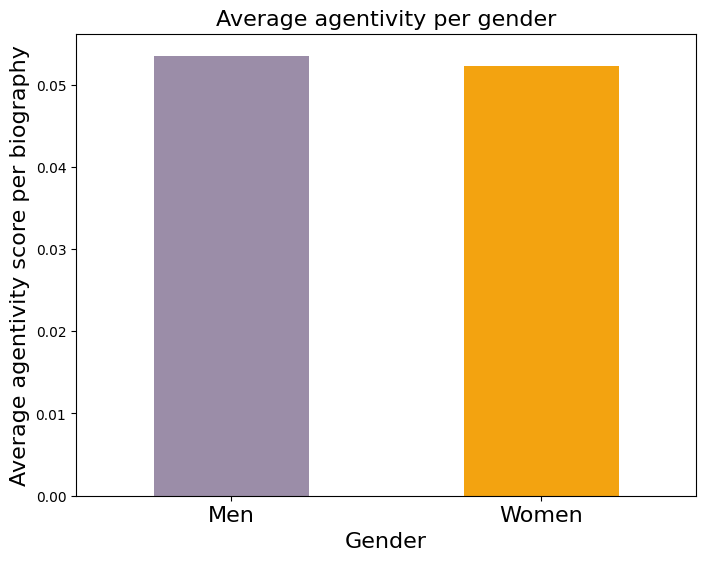

In [81]:
# Printing results

gender_means = df_analysis.groupby('Gender')['active_count_len_ratio'].mean()

plt.figure(figsize=(8, 6))

gender_means.plot(kind='bar', color=["#9b8da8", "#F3A310"])

plt.title('Average agentivity per gender', fontsize=16)
plt.xlabel('Gender', fontsize=16)
plt.ylabel('Average agentivity score per biography', fontsize=16)
plt.xticks([0, 1], ['Men', 'Women'], rotation=0, fontsize=16)

Men seem to be a tiny bit more agentive than women when it comes to active verbs.

In [82]:
# Testing the distribution

df_stats = df_analysis.copy()

men = df_stats[df_stats['Gender'] == 'Men']['active_count_len_ratio'].dropna()
women = df_stats[df_stats['Gender'] == 'Women']['active_count_len_ratio'].dropna()

stat_h, p_norm_h = stats.shapiro(men)
stat_f, p_norm_f = stats.shapiro(women)
print(f"[Normality] Men group : p-value = {p_norm_h:.4f}")
print(f"[Normality] Women group : p-value = {p_norm_f:.4f}")

if p_norm_h < 0.05 or p_norm_f < 0.05:
    print("-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).")
else:
    print("-> The data are normally distributed. Using Student's t-test.")

[Normality] Men group : p-value = 0.0000
[Normality] Women group : p-value = 0.0000
-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).


In [83]:
# Performing Mann-Whitney test

stat_mw, p_mw = stats.mannwhitneyu(men, women, alternative='two-sided')
print(f"\nMann-Whitney results : p-value = {p_mw:.4e}")

if p_mw < 0.05:
    print("-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).")
else:
    print("-> CONCLUSION: The difference in agency is not statistically significant.")


Mann-Whitney results : p-value = 1.0598e-04
-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).


### 1.2 Analysis per gender and sport category

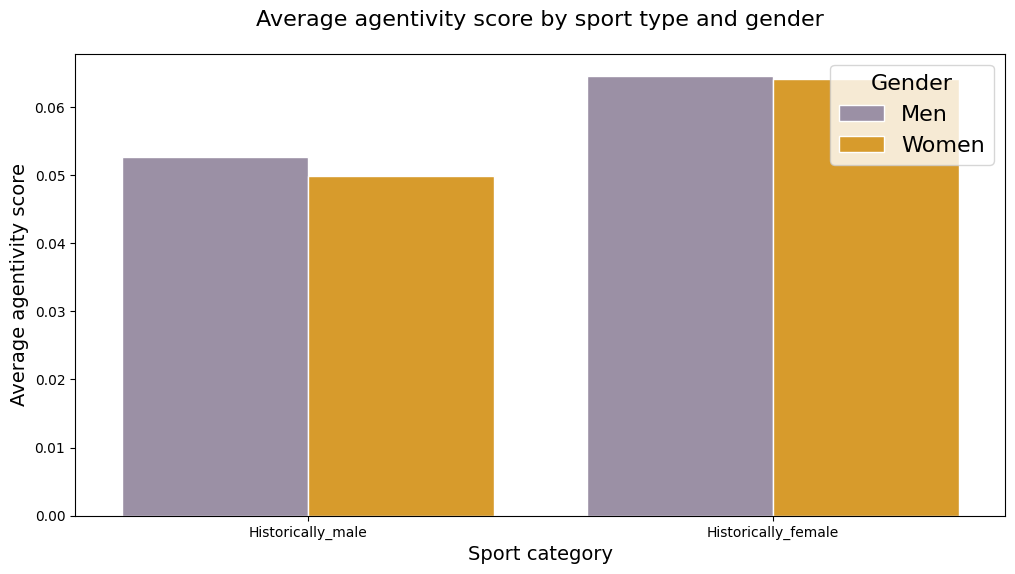

In [84]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_analysis, 
    x='sport_type',  
    y='active_count_len_ratio', 
    hue='Gender',      
    palette={"Men": "#9b8da8", "Women": "#F3A310"}, 
    errorbar=None,     
    edgecolor='white'
)

plt.title('Average agentivity score by sport type and gender', fontsize=16, pad=20)
plt.xlabel('Sport category', fontsize=14)
plt.ylabel('Average agentivity score', fontsize=14)
plt.legend(title='Gender', title_fontsize='16', fontsize='16')

Men seem to be a bit more agentive than women in both sports categories, when it comes to agentive verbs.

Text(0, 0.5, 'Frequency')

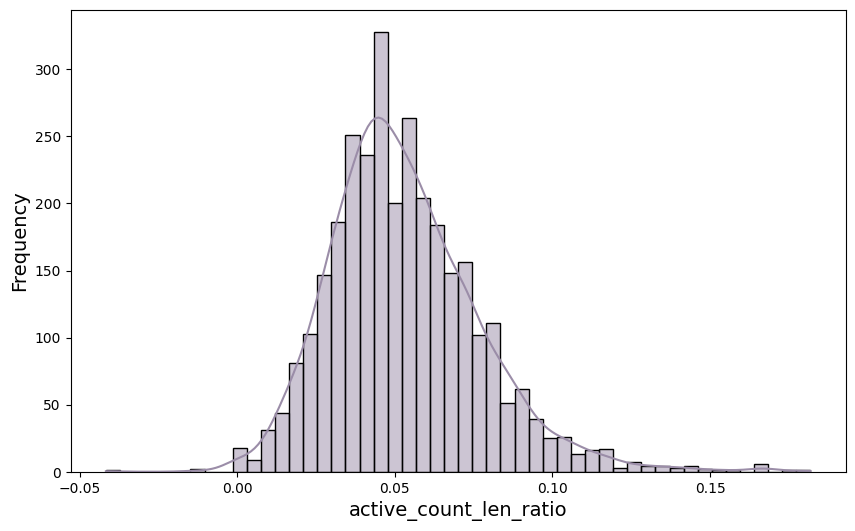

In [85]:
# Checking distribution of active_count_len_ratio

plt.figure(figsize=(10, 6))

# Printing histogramm of the variable
sns.histplot(df_analysis['active_count_len_ratio'], kde=True, color="#9b8da8", bins=50)

plt.xlabel('active_count_len_ratio', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

The variable is log distributed.

In [86]:
# Applying log transformation because active_count_len_ratio variable is log distributed (see previous graphic)
df_analysis['log_active_count_len_ratio'] = np.log1p(df_analysis['active_count_len_ratio'])  # this function calculate ln(x+1). It's used to have only positive values otherwise, anova test crashes

# Anova test
model_log = smf.ols('log_active_count_len_ratio ~ C(Gender) * C(sport_type)', data=df_analysis).fit()
anova_log = sm.stats.anova_lm(model_log, typ=2)
print(anova_log)
p_value_interaction = anova_log.loc['C(Gender):C(sport_type)', 'PR(>F)']

# Printing result
if p_value_interaction < 0.05:
    print("Conclusion : The interaction effect IS significant. This provides scientific proof that the gender gap in agency varies depending on the type of sport.")
else:
    print("Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.")

                           sum_sq      df          F        PR(>F)
C(Gender)                0.004367     1.0   8.865065  2.929393e-03
C(sport_type)            0.039748     1.0  80.681787  4.508508e-19
C(Gender):C(sport_type)  0.000314     1.0   0.637841  4.245550e-01
Residual                 1.521313  3088.0        NaN           NaN
Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.


To conclude on this part, the distributions of active verbs only very similar to the distributions of all verbs. Therefore, statistical results are the same: there's a significant difference in terms of agency across gender but there's no significant difference across gender and sport categories.

## 2. Passive verbs

### 2.1 Analysis per gender

([<matplotlib.axis.XTick at 0x1f1f72af150>,
 [Text(0, 0, 'Men'), Text(1, 0, 'Women')])

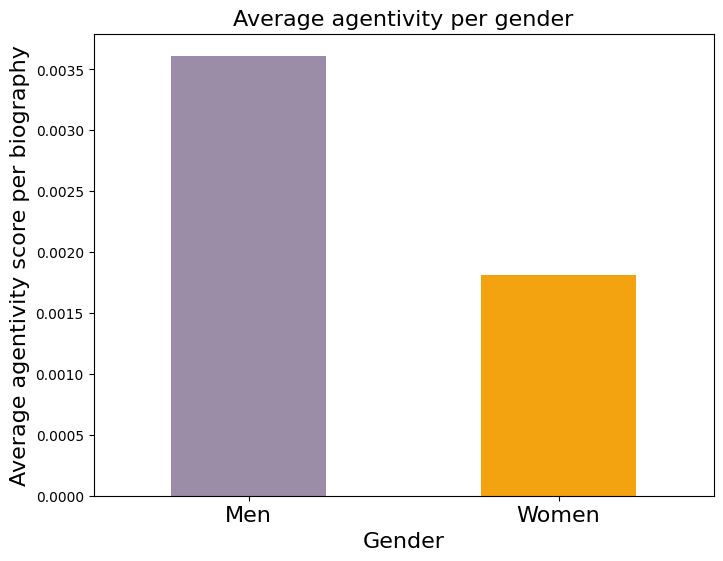

In [87]:
# Printing results

gender_means = df_analysis.groupby('Gender')['passive_count_len_ratio'].mean()

plt.figure(figsize=(8, 6))

gender_means.plot(kind='bar', color=["#9b8da8", "#F3A310"])

plt.title('Average agentivity per gender', fontsize=16)
plt.xlabel('Gender', fontsize=16)
plt.ylabel('Average agentivity score per biography', fontsize=16)
plt.xticks([0, 1], ['Men', 'Women'], rotation=0, fontsize=16)

Men seem to be much more agentive than women when it comes to passive verbs. Though, the scale is very low so this effect is not that important.

In [88]:
# Testing the distribution

df_stats = df_analysis.copy()

men = df_stats[df_stats['Gender'] == 'Men']['passive_count_len_ratio'].dropna()
women = df_stats[df_stats['Gender'] == 'Women']['passive_count_len_ratio'].dropna()

stat_h, p_norm_h = stats.shapiro(men)
stat_f, p_norm_f = stats.shapiro(women)
print(f"[Normality] Men group : p-value = {p_norm_h:.4f}")
print(f"[Normality] Women group : p-value = {p_norm_f:.4f}")

if p_norm_h < 0.05 or p_norm_f < 0.05:
    print("-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).")
else:
    print("-> The data are normally distributed. Using Student's t-test.")

[Normality] Men group : p-value = 0.0000
[Normality] Women group : p-value = 0.0000
-> The data are NOT normally distributed. Use the nonparametric test (Mann-Whitney).


In [90]:
# Performing Mann-Whitney test

stat_mw, p_mw = stats.mannwhitneyu(men, women, alternative='two-sided')
print(f"\nMann-Whitney results : p-value = {p_mw:.4e}")

if p_mw < 0.05:
    print("-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).")
else:
    print("-> CONCLUSION: The difference in agency is not statistically significant.")



Mann-Whitney results : p-value = 8.3116e-14
-> CONCLUSION: There is a STATISTICALLY SIGNIFICANT difference in agency between men and women (p < 0.05).


### 2.2 Analysis per gender and sport category

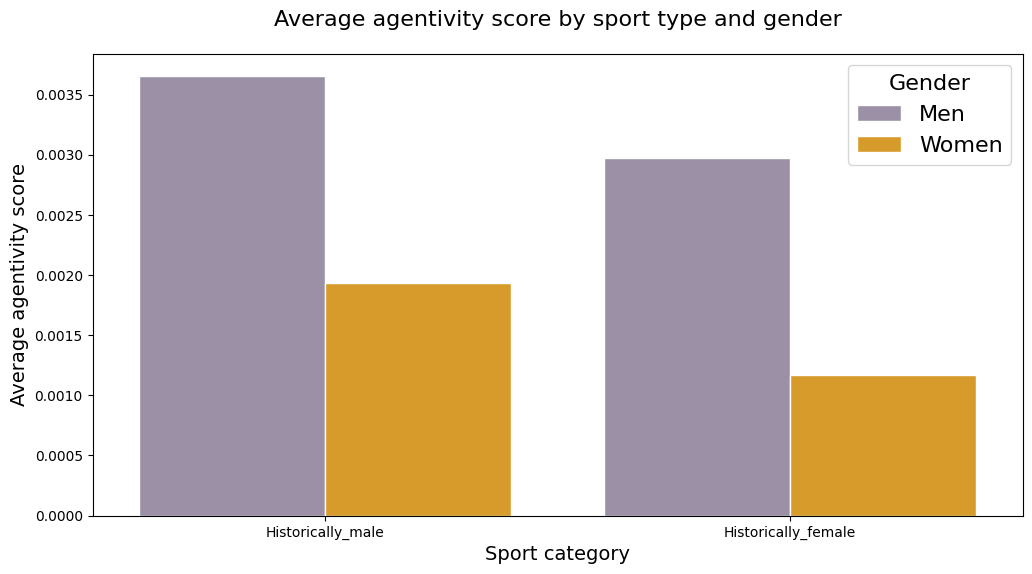

In [91]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_analysis, 
    x='sport_type',  
    y='passive_count_len_ratio', 
    hue='Gender',      
    palette={"Men": "#9b8da8", "Women": "#F3A310"}, 
    errorbar=None,     
    edgecolor='white'
)

plt.title('Average agentivity score by sport type and gender', fontsize=16, pad=20)
plt.xlabel('Sport category', fontsize=14)
plt.ylabel('Average agentivity score', fontsize=14)
plt.legend(title='Gender', title_fontsize='16', fontsize='16')

Men seem to be more agentive than women in both categories.

Text(0, 0.5, 'Frequency')

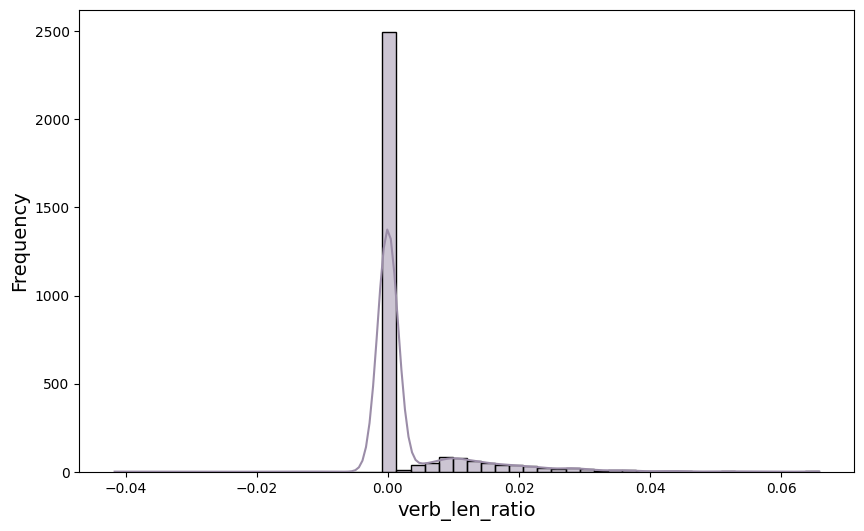

In [92]:
# Checking distribution of verb_len_ratio

plt.figure(figsize=(10, 6))

# Printing histogramm of the variable
sns.histplot(df_analysis['passive_count_len_ratio'], kde=True, color="#9b8da8", bins=50)

plt.xlabel('verb_len_ratio', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

The variable is log distributed.

In [93]:
# Applying log transformation because passive_count_len_ratio variable is log distributed (see previous graphic)
df_analysis['log_passive_count_len_ratio'] = np.log1p(df_analysis['passive_count_len_ratio'])

# Anova test
model_log = smf.ols('log_passive_count_len_ratio ~ C(Gender) * C(sport_type)', data=df_analysis).fit()
anova_log = sm.stats.anova_lm(model_log, typ=2)
print(anova_log)
p_value_interaction = anova_log.loc['C(Gender):C(sport_type)', 'PR(>F)']

# Printing result
if p_value_interaction < 0.05:
    print("Conclusion : The interaction effect IS significant. This provides scientific proof that the gender gap in agency varies depending on the type of sport.")
else:
    print("Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.")

                               sum_sq      df          F        PR(>F)
C(Gender)                1.879947e-03     1.0  32.432091  1.350179e-08
C(sport_type)            1.380672e-04     1.0   2.381881  1.228522e-01
C(Gender):C(sport_type)  3.617499e-07     1.0   0.006241  9.370389e-01
Residual                 1.789979e-01  3088.0        NaN           NaN
Conclusion : The interaction effect is NOT significant. The difference in agency between men and women remains the same regardless of the type of sport.


To conclude on this part, the distributions of passive verbs are very different from the distributions of the sum of all verbs. Indeed, there a much more passive verbs for men than for women. Though, statistical results are the same: there's a significant difference in terms of agency across gender but there's no significant difference across gender and sport categories.

The replication of the results with different types of verbs increases their strength. 